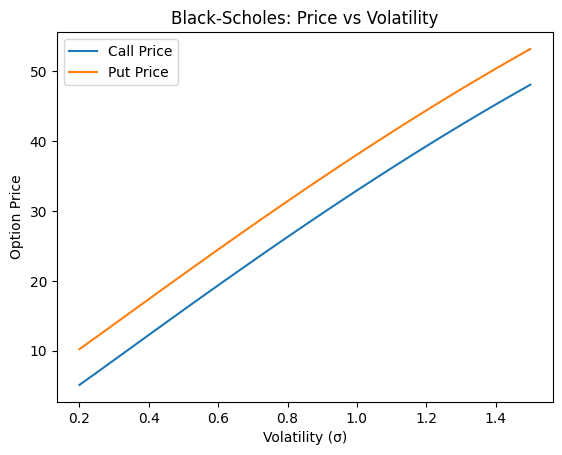

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from blackscholes import call_price, put_price


# -------------------------
# Parameters (base case)
# -------------------------
S = 90    # stock price
K = 100      # strike price
T = 1        # time to expiry (1 year)
r = 0.05     # risk-free rate


# -------------------------
# Volatility range
# -------------------------
sigmas = np.linspace(0.2, 1.5, 50)
call_prices = []
put_prices = []


# -------------------------
# Compute prices
# -------------------------
for sigma in sigmas:
    call_prices.append(call_price(S, K, T, r, sigma))
    put_prices.append(put_price(S, K, T, r, sigma))


# -------------------------
# Plot results
# -------------------------
plt.plot(sigmas, call_prices, label="Call Price")
plt.plot(sigmas, put_prices, label="Put Price")

plt.xlabel("Volatility (σ)")
plt.ylabel("Option Price")
plt.title("Black-Scholes: Price vs Volatility")
plt.legend()

plt.show()

In [3]:
from blackscholes import delta

print(delta(100, 100, 1, 0.05, 0.2, option_type='call'))
print(delta(100, 100, 1, 0.05, 0.2, option_type='put'))

0.6368306511756191
-0.3631693488243809


In [4]:
from blackscholes import gamma

print(gamma(100, 100, 1, 0.05, 0.2))

0.018762017345846895


In [1]:
from blackscholes import vega
print(vega(100, 100, 1, 0.05, 0.2))

37.52403469169379


In [2]:
from blackscholes import theta
print(theta(100, 100, 1, 0.05, 0.2, option_type='call'))
print(theta(100, 100, 1, 0.05, 0.2, option_type='put'))

-6.414027546438197
-1.657880423934626


In [1]:
from blackscholes import rho
print(rho(100, 100, 1, 0.05, 0.2, option_type='call'))
print(rho(100, 100, 1, 0.05, 0.2, option_type='put'))

53.232481545376345
-41.89046090469506


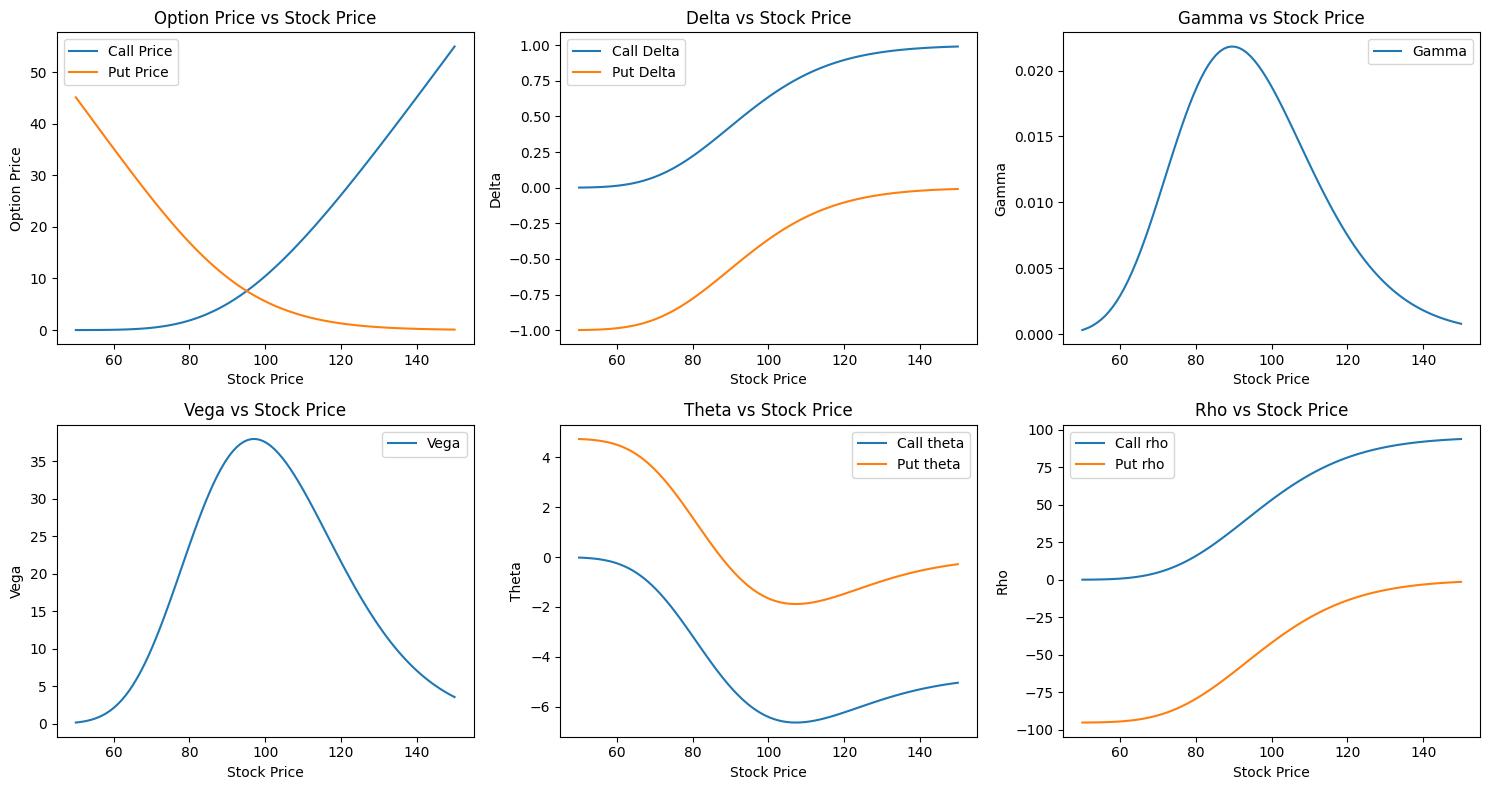

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
import numpy as np

from blackscholes import delta, rho , theta, vega, gamma, call_price, put_price
S_range = np.linspace(50, 150, 100)
K = 100
T = 1
r = 0.05
sigma = 0.2
call_prices = []
put_prices = []
delta_values_call = []
delta_values_put = []
rho_values_call = []
rho_values_put = []
theta_values_call = []
theta_values_put = []
vega_values = []
gamma_values = []
for S in S_range:
    call_prices.append(call_price(S, K, T, r, sigma))
    put_prices.append(put_price(S, K, T, r, sigma))
    rho_call = rho(S, K, T, r, sigma, option_type='call')
    rho_values_call.append(rho_call)
    rho_put = rho(S, K, T, r, sigma, option_type='put')
    rho_values_put.append(rho_put)
    theta_call = theta(S, K, T, r, sigma, option_type='call')
    theta_values_call.append(theta_call)
    theta_put = theta(S, K, T, r, sigma, option_type='put')
    theta_values_put.append(theta_put)
    vega_value = vega(S, K, T, r, sigma)
    vega_values.append(vega_value)
    gamma_value = gamma(S, K, T, r, sigma)
    gamma_values.append(gamma_value)
    delta_call = delta(S, K, T, r, sigma, option_type='call')
    delta_values_call.append(delta_call)
    delta_put = delta(S, K, T, r, sigma, option_type='put')
    delta_values_put.append(delta_put)

# -------------------------
# Plot results
# -------------------------
axes[0][0].plot(S_range, call_prices, label="Call Price")
axes[0][0].plot(S_range, put_prices, label="Put Price")
axes[0][0].set_xlabel("Stock Price")
axes[0][0].set_ylabel("Option Price")
axes[0][0].set_title("Option Price vs Stock Price")
axes[0][0].legend()

axes[0][1].plot(S_range, delta_values_call, label='Call Delta')
axes[0][1].plot(S_range, delta_values_put, label='Put Delta')
axes[0][1].set_xlabel('Stock Price')
axes[0][1].set_ylabel('Delta')
axes[0][1].set_title('Delta vs Stock Price')
axes[0][1].legend()

axes[0][2].plot(S_range, gamma_values, label='Gamma')
axes[0][2].set_xlabel('Stock Price')
axes[0][2].set_ylabel('Gamma')
axes[0][2].set_title('Gamma vs Stock Price')
axes[0][2].legend()

axes[1][0].plot(S_range, vega_values, label='Vega')
axes[1][0].set_xlabel('Stock Price')
axes[1][0].set_ylabel('Vega')
axes[1][0].set_title('Vega vs Stock Price')
axes[1][0].legend()

axes[1][1].plot(S_range, theta_values_call, label='Call theta')
axes[1][1].plot(S_range, theta_values_put, label='Put theta')
axes[1][1].set_xlabel('Stock Price')
axes[1][1].set_ylabel('Theta')
axes[1][1].set_title('Theta vs Stock Price')
axes[1][1].legend()

axes[1][2].plot(S_range, rho_values_call, label='Call rho')
axes[1][2].plot(S_range, rho_values_put, label='Put rho')
axes[1][2].set_xlabel('Stock Price')
axes[1][2].set_ylabel('Rho')
axes[1][2].set_title('Rho vs Stock Price')
axes[1][2].legend()

plt.tight_layout()
plt.show()













In [3]:
from blackscholes import simulate_path
print(simulate_path(100, 0.05, 0.2, 1, 252))

136.63385187093266


In [1]:
from blackscholes import monte_carlo

print(monte_carlo(100, 100, 1, 0.05, 0.2, option_type='call'))
print(monte_carlo(100, 100, 1, 0.05, 0.2, option_type='put'))

10.691539384236671
5.508281596016241


In [2]:
print(monte_carlo(100, 100, 1, 0.05, 0.2, option_type='call', simulations=100000))

10.476855650145836


In [1]:
from blackscholes import implied_vol

# We know call price is 10.45 with sigma=0.2
# So implied vol should give us back 0.2
print(implied_vol(10.45, 100, 100, 1, 0.05, option_type='call'))

0.19998444804269158
